In [1]:
!pip install xmltodict

In [101]:
import requests
import pandas as pd
import numpy as np
import xmltodict
import pprint
import matplotlib.pyplot as plt
import koreanize_matplotlib
import time
import math
import folium

# 1. API 설정
api_key = "91b89db582a8b4e32560db475314eadfb1d2cd6aa256a914a381aa06e0d7cb4e"
url = "http://apis.data.go.kr/B552584/EvCharger/getChargerInfo"
def get_charger_page(page_no, zcode="29", num_of_rows=9999):
    params = {
        "serviceKey": api_key,
        "pageNo": str(page_no),          # 하드코딩 금지
        "numOfRows": str(num_of_rows),   # 하드코딩 금지
        "zcode": zcode,
        "dataType": "xml"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = xmltodict.parse(response.text)
    body = data["response"]["body"]

    total_count = int(body.get("totalCount", 0))
    items = body.get("items", {})
    item_list = items.get("item", [])

    if isinstance(item_list, dict):
        item_list = [item_list]

    return item_list, total_count


# 1페이지 테스트
items_1, total_count = get_charger_page(page_no=1, zcode="29", num_of_rows=9999)
print("API가 알려주는 전체 건수 total_count:", total_count)
print("1페이지에서 받은 건수:", len(items_1))

# 전체 페이지 수집
all_items = []
page_no = 1
num_of_rows = 9999

while True:
    items, total_count = get_charger_page(
        page_no=page_no,
        zcode="29",
        num_of_rows=num_of_rows
    )

    print(f"{page_no}페이지 / 이번 페이지 {len(items)}건 / total_count={total_count}")

    if not items:
        break

    all_items.extend(items)

    if len(all_items) >= total_count:
        break

    page_no += 1
    time.sleep(0.3)

df = pd.DataFrame(all_items)

print("최종 행 수:", len(df))
print("충전소명 기준 개수:", df["statNm"].nunique() if "statNm" in df.columns else "statNm 컬럼 없음")
print(df.head())

API가 알려주는 전체 건수 total_count: 0
1페이지에서 받은 건수: 9999
1페이지 / 이번 페이지 9999건 / total_count=0
최종 행 수: 9999
충전소명 기준 개수: 2451
            statNm    statId chgerId chgerType                     addr  \
0           한국광기술원  ME181501      01        06  광주광역시 북구 첨단 벤처로 108번길 9   
1         롯데마트 수완점  ME181545      01        06         광주광역시 광산구 장신로 98   
2         롯데마트 수완점  ME181545      11        06         광주광역시 광산구 장신로 98   
3  블루핸즈 하남현대자동차서비스  ME183018      01        06    광주광역시 광산구 하남대로 127-10   
4        기아자동차 진월점  ME183019      01        06       광주광역시 남구 진월동 314-1   

  addrDetail location           lat           lng      useTime  ...  note  \
0       null     null  35.231341167  126.85982174    24시간 이용가능  ...  None   
1       null     null     35.190126    126.820343  10:00~23:00  ...  None   
2       null     null     35.190126    126.820343  10:00~23:00  ...  None   
3       null     null    35.1810177   126.8074485    24시간 이용가능  ...  None   
4       null     null     35.124734   126.897109

In [103]:
print("전체 데이터 수:", total_count)
print("1페이지 데이터 수:", len(items))
print(len(df))
print(df['statNm'].nunique())

전체 데이터 수: 0
1페이지 데이터 수: 9999
9999
2451


In [45]:
df.columns

Index(['statNm', 'statId', 'chgerId', 'chgerType', 'addr', 'addrDetail',
       'location', 'lat', 'lng', 'useTime', 'busiId', 'bnm', 'busiNm',
       'busiCall', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt',
       'powerType', 'output', 'method', 'zcode', 'zscode', 'kind',
       'kindDetail', 'parkingFree', 'note', 'limitYn', 'limitDetail', 'delYn',
       'delDetail', 'trafficYn', 'year', 'floorNum', 'floorType', 'maker'],
      dtype='object')

In [104]:
df = df[['statNm','addr','chgerType', 'useTime', 'lat', 'lng']]
df.head()

,statNm,addr,chgerType,useTime,lat,lng
0,한국광기술원,광주광역시 북구 첨단 벤처로 108번길 9,06,24시간 이용가능,35.231341167,126.85982174
1,롯데마트 수완점,광주광역시 광산구 장신로 98,06,10:00~23:00,35.190126,126.820343
2,롯데마트 수완점,광주광역시 광산구 장신로 98,06,10:00~23:00,35.190126,126.820343
3,블루핸즈 하남현대자동차서비스,광주광역시 광산구 하남대로 127-10,06,24시간 이용가능,35.1810177,126.8074485
4,기아자동차 진월점,광주광역시 남구 진월동 314-1,06,24시간 이용가능,35.124734,126.8971093


In [105]:
df.useTime=df.useTime.fillna('정보없음')
df.isnull().sum()

statNm       0
addr         0
chgerType    0
useTime      0
lat          0
lng          0
dtype: int64

In [106]:
df = df.drop_duplicates(subset='statNm')
df

,statNm,addr,chgerType,useTime,lat,lng
0,한국광기술원,광주광역시 북구 첨단 벤처로 108번길 9,06,24시간 이용가능,35.231341167,126.85982174
1,롯데마트 수완점,광주광역시 광산구 장신로 98,06,10:00~23:00,35.190126,126.820343
3,블루핸즈 하남현대자동차서비스,광주광역시 광산구 하남대로 127-10,06,24시간 이용가능,35.1810177,126.8074485
4,기아자동차 진월점,광주광역시 남구 진월동 314-1,06,24시간 이용가능,35.124734,126.8971093
5,이마트 광산점,광주광역시 광산구 사암로 172,06,10:00~24:00,35.160050,126.809050
...,...,...,...,...,...,...
9976,무등파크 봉선3차1단지,광주광역시 남구 용대로 90-1,02,08:00~20:00,35.123347647,126.91877640
9981,광주효천LH천년나무1단지,광주광역시 남구 효우로 262,02,08:00~20:00,35.103323,126.886899
9986,황금주차빌딩,광주광역시 동구 서석로 29-2,02,08:00~20:00,35.146386232,126.91680664
9991,산수동 라도스하임,광주광역시 동구 필문대로192번길 21,02,08:00~20:00,35.153179830,126.92921245


In [107]:
df.chgerType.dtype

dtype('O')

In [127]:
conditions = [
    (df['chgerType']=='01'),
    (df['chgerType']=='02'),
    (df['chgerType']=='03'),
    (df['chgerType']=='04'),
    (df['chgerType']=='05'),
    (df['chgerType']=='06')
]

choice = ['완속','AC완속','AC3상','DC콤보','DC데모+콤보','AC3상+DC']

df['chgerType_name'] = np.select(conditions, choice, default='기타')
df.chgerType_name

0       AC3상+DC
1       AC3상+DC
3       AC3상+DC
4       AC3상+DC
5       AC3상+DC
         ...   
9976       AC완속
9981       AC완속
9986       AC완속
9991       AC완속
9994       AC완속
Name: chgerType_name, Length: 2451, dtype: object

In [128]:
df['useTime_TF'] = df.useTime.str.contains('24시간')
df.useTime_TF
df['24시간이용가능여부'] = df.useTime_TF.map({True:'24시간 이용가능', False:'24시간이용불가'})

In [110]:
df.head()

,statNm,addr,chgerType,useTime,lat,lng,chgerType_name,useTime_TF,24시간이용가능여부
0,한국광기술원,광주광역시 북구 첨단 벤처로 108번길 9,06,24시간 이용가능,35.231341167,126.85982174,초급속,True,24시간 이용가능
1,롯데마트 수완점,광주광역시 광산구 장신로 98,06,10:00~23:00,35.190126,126.820343,초급속,False,24시간이용불가
3,블루핸즈 하남현대자동차서비스,광주광역시 광산구 하남대로 127-10,06,24시간 이용가능,35.1810177,126.8074485,초급속,True,24시간 이용가능
4,기아자동차 진월점,광주광역시 남구 진월동 314-1,06,24시간 이용가능,35.124734,126.8971093,초급속,True,24시간 이용가능
5,이마트 광산점,광주광역시 광산구 사암로 172,06,10:00~24:00,35.160050,126.809050,초급속,False,24시간이용불가


In [129]:
df['addr_gu'] = df.addr.str.extract('(광산구|동구|북구|남구|서구)')
df.head()

,statNm,addr,chgerType,useTime,lat,lng,chgerType_name,useTime_TF,24시간이용가능여부,addr_gu
0,한국광기술원,광주광역시 북구 첨단 벤처로 108번길 9,06,24시간 이용가능,35.231341167,126.85982174,AC3상+DC,True,24시간 이용가능,북구
1,롯데마트 수완점,광주광역시 광산구 장신로 98,06,10:00~23:00,35.190126,126.820343,AC3상+DC,False,24시간이용불가,광산구
3,블루핸즈 하남현대자동차서비스,광주광역시 광산구 하남대로 127-10,06,24시간 이용가능,35.1810177,126.8074485,AC3상+DC,True,24시간 이용가능,광산구
4,기아자동차 진월점,광주광역시 남구 진월동 314-1,06,24시간 이용가능,35.124734,126.8971093,AC3상+DC,True,24시간 이용가능,남구
5,이마트 광산점,광주광역시 광산구 사암로 172,06,10:00~24:00,35.160050,126.809050,AC3상+DC,False,24시간이용불가,광산구


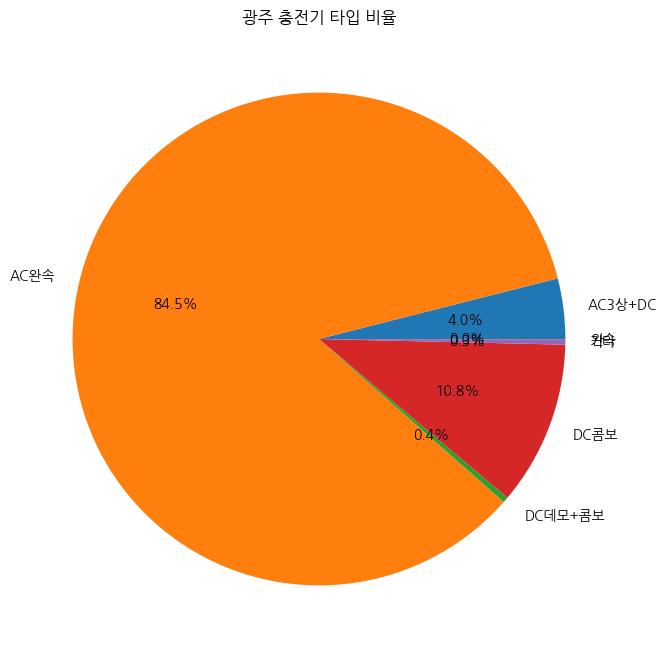

In [130]:
g = pd.crosstab(df['addr_gu'], df['chgerType_name'])

g.sum().plot.pie(
    figsize=(8,8),
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('광주 충전기 타입 비율')

plt.show()

In [113]:
df.columns

Index(['statNm', 'addr', 'chgerType', 'useTime', 'lat', 'lng',
       'chgerType_name', 'useTime_TF', '24시간이용가능여부', 'addr_gu'],
      dtype='object')

In [114]:
df.useTime.info()

<class 'pandas.core.series.Series'>
Index: 2451 entries, 0 to 9994
Series name: useTime
Non-Null Count  Dtype 
--------------  ----- 
2451 non-null   object
dtypes: object(1)
memory usage: 38.3+ KB


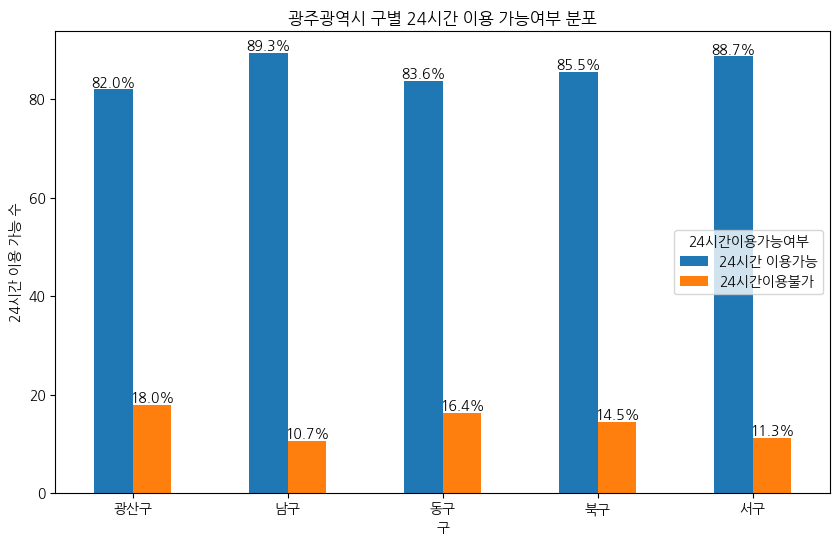

In [131]:
d = pd.crosstab(df.addr_gu, df['24시간이용가능여부'], normalize='index') * 100

ax = d.plot.bar(figsize=(10,6))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
    
plt.xlabel('구')
plt.xticks(rotation=0)
plt.ylabel('24시간 이용 가능 수')
plt.title('광주광역시 구별 24시간 이용 가능여부 분포')

plt.show()


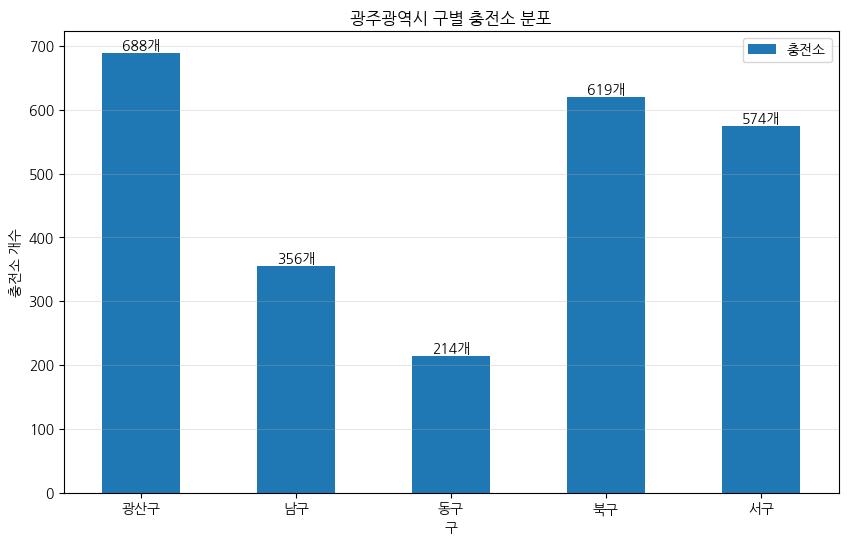

In [132]:
c = pd.crosstab(df['addr_gu'],columns='count')
c.columns = ['충전소']

ax = c.plot.bar(figsize=(10,6))

for container in ax.containers:
    ax.bar_label(container, fmt='%d개')

plt.xlabel('구')
plt.xticks(rotation=0)
plt.ylabel('충전소 개수')
plt.title('광주광역시 구별 충전소 분포')
plt.grid(axis='y', alpha=0.3)

plt.show()


In [ ]:
car_registered = {
    '북구' : 3648
    '광산구': 3639,
    '서구': 8138,
    '남구': 207597,
    '동구': 106203
}

In [133]:
charger_per_station = df.groupby(df['statNm']).size()

charger_per_station.mean()

np.float64(1.0)

In [118]:
m = folium.Map(location=[35.16,126.85], zoom_start=12)

for _, row in df.sample(300).iterrows():
    folium.CircleMarker(
        location=[float(row['lat']), float(row['lng'])],
        radius=3
    ).add_to(m)

m

In [142]:
#충전기 밀도 => 충전기 수 / 인구 
population = {
    '북구': 423961,
    '광산구': 391611,
    '서구': 279050,
    '남구': 207597,
    '동구': 106203
}
charger_count = df.addr_gu.value_counts().sort_index()
density = (charger_count / pd.Series(population) * 10000).round(2)
density 

광산구    17.57
남구     17.15
동구     20.15
북구     14.60
서구     20.57
dtype: float64

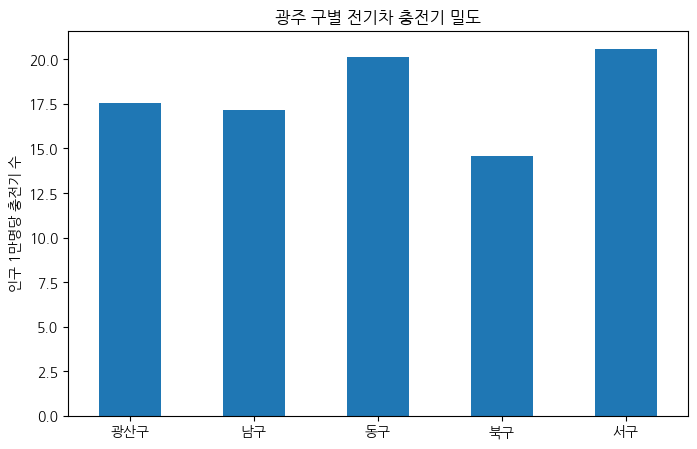

In [135]:
density.plot.bar(figsize=(8,5))

plt.ylabel('인구 1만명당 충전기 수')
plt.title('광주 구별 전기차 충전기 밀도')

plt.xticks(rotation=0)

plt.show()

In [143]:
map_df = pd.DataFrame({
    'addr_gu': ['동구', '서구', '남구', '북구', '광산구'],
    'lat': [35.1461, 35.1528, 35.1330, 35.1741, 35.1396],
    'lng': [126.9231, 126.8907, 126.9025, 126.9113, 126.7930]
})

map_df['charger_count'] = map_df['addr_gu'].map(charger_count)
map_df['density'] = map_df['addr_gu'].map(density)

m = folium.Map(location=[35.16, 126.85], zoom_start=11)

for _, row in map_df.iterrows():
    folium.Circle(
        location=[row['lat'], row['lng']],
        radius=row['density'] * 150,
        popup=(
            f"{row['addr_gu']}<br>"
            f"충전기 수: {int(row['charger_count'])}개<br>"
            f"밀도: {row['density']}개 / 1만명"
        ),
        tooltip=f"{row['addr_gu']} : {row['density']}개/1만명",
        color='blue',
        fill=True,
        fill_opacity=0.4
    ).add_to(m)

m